# Ex 07
# Denoising Autoencoder
NAME : VIJAYARAGHAVAN  REG NO : 212225100058 

In [21]:
!pip install torchsummary

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

from torchsummary import summary

print("Libraries imported successfully!")

Libraries imported successfully!


In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [24]:
transform = transforms.Compose([
    transforms.ToTensor()
])

print("Transform created successfully!")

Transform created successfully!


In [25]:
dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [26]:
train_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 469
Testing batches: 79


In [27]:
def add_noise(inputs, noise_factor=0.5):

    noisy = inputs + noise_factor * torch.randn_like(inputs)

    noisy = torch.clamp(
        noisy,
        0.0,
        1.0
    )

    return noisy


print("Noise function created successfully!")

Noise function created successfully!


In [28]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(
                1, 16,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                16, 1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [29]:
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Model initialized successfully!")
print("Loss Function: MSELoss")
print("Optimizer: Adam")

Model initialized successfully!
Loss Function: MSELoss
Optimizer: Adam


In [30]:
sample_input = torch.randn(
    1, 1, 28, 28
).to(device)

sample_output = model(sample_input)

print("Input shape :", sample_input.shape)
print("Output shape:", sample_output.shape)

Input shape : torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 1, 28, 28])


In [31]:
def train(
    model,
    loader,
    criterion,
    optimizer,
    epochs=5
):

    model.train()

    train_losses = []

    print("Name: VIJAYARAGHAVAN M")
    print("Register Number: 212225100058")
    print("-" * 50)

    for epoch in range(epochs):

        running_loss = 0.0

        for images, _ in loader:

            images = images.to(device)

            noisy_images = add_noise(images)

            outputs = model(noisy_images)

            loss = criterion(
                outputs,
                images
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)

        train_losses.append(epoch_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {epoch_loss:.4f}"
        )

    return train_losses

In [32]:
train_losses = train(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=5
)

print("\nTraining completed successfully!")

Name: VIJAYARAGHAVAN M
Register Number: 212225100058
--------------------------------------------------
Epoch [1/5], Loss: 0.0517
Epoch [2/5], Loss: 0.0155
Epoch [3/5], Loss: 0.0147
Epoch [4/5], Loss: 0.0144
Epoch [5/5], Loss: 0.0141

Training completed successfully!


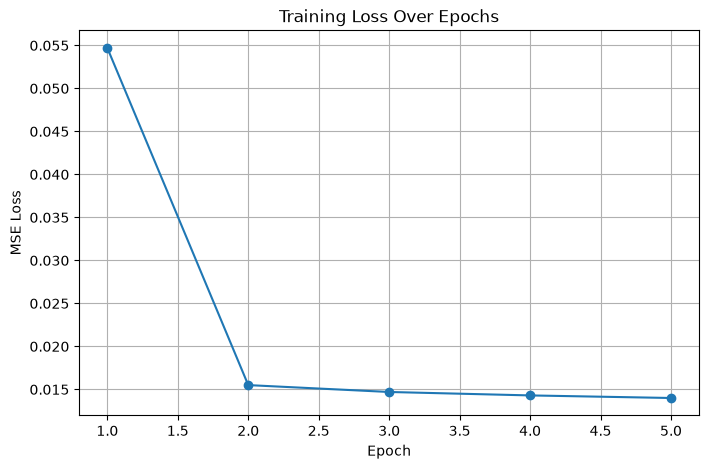

In [33]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]
loss = [0.0547, 0.0155, 0.0147, 0.0143, 0.0140]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    loss,
    marker="o"
)

plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.show()

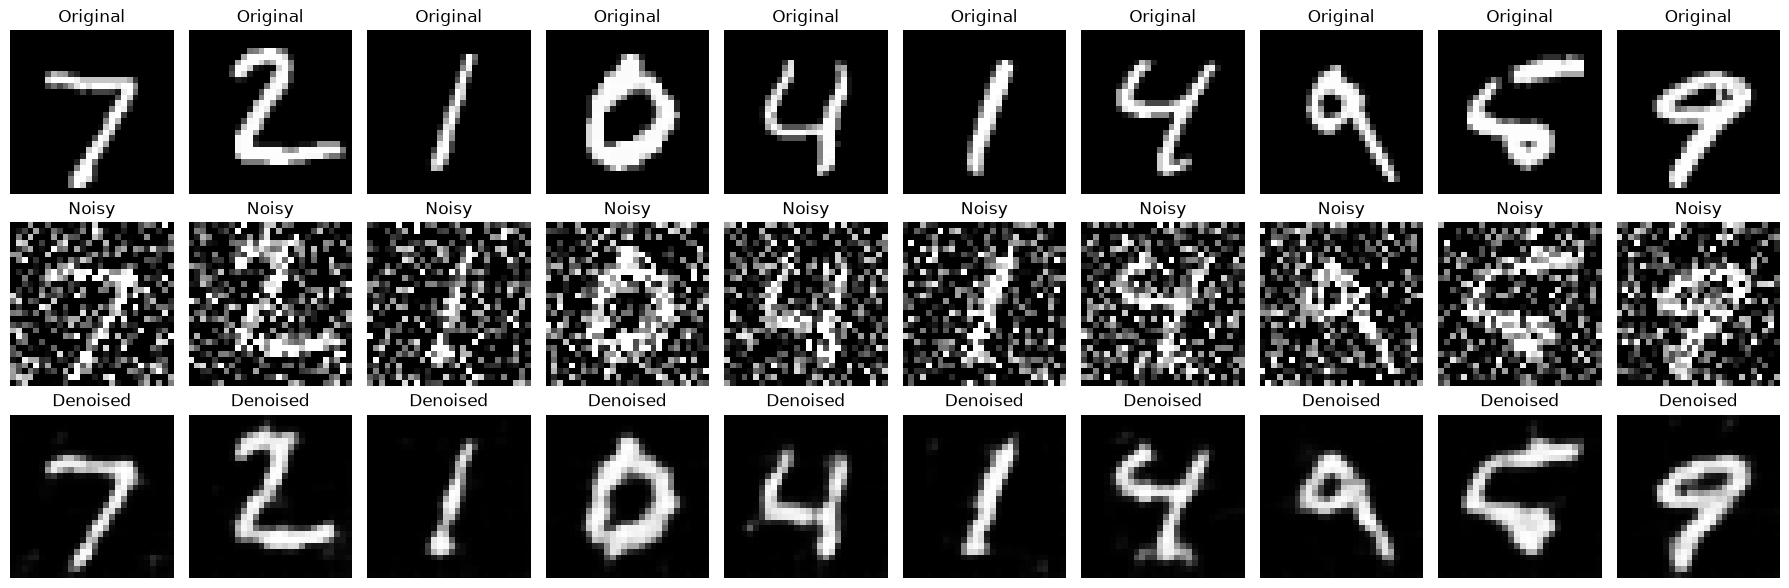

In [35]:
model.eval()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        noisy_images = add_noise(images)

        outputs = model(noisy_images)

        break

images = images.cpu().numpy()
noisy_images = noisy_images.cpu().numpy()
outputs = outputs.cpu().numpy()

num_images = 10

plt.figure(figsize=(18, 6))

for i in range(num_images):

    # Original
    ax = plt.subplot(3, num_images, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, num_images, i + 1 + num_images)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    ax.set_title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
    plt.imshow(outputs[i].squeeze(), cmap="gray")
    ax.set_title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("        DENOISING AUTOENCODER - FINAL RESULT")
print("=" * 60)
print("Name            : VIJAYARAGHAVAN")
print("Register Number : 21222510005858")
print("Dataset         : MNIST")
print("Model           : Denoising Autoencoder")
print("Task            : Image Denoising")
print("Epochs          : 5")
print("Batch Size      : 128")
print("Learning Rate   : 0.001")
print("Device          :", device)
print("=" * 60)
print("Training and Denoising Completed Successfully!")

In [ ]:
from torchsummary import summary

summary(model, input_size=(1, 28, 28))